--- Step 1: Extracting and Loading Dataset ---
Extracted zip file contents to: /content/telco_churn_extracted
Loading data from: /content/telco_churn_extracted/Telco_Churn_Dataset.csv
Dataset loaded successfully with shape: (7043, 21)

--- Step 2: Preparing Preprocessing Pipelines ---
Numeric features detected: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features detected: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Data split completed (80% Train, 20% Test).

--- Step 3: Model Training & Hyperparameter Tuning ---
Starting Grid Search across Logistic Regression & Random Forest architectures...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Model Found: LogisticRegression
Best Cross-Validation ROC-AUC Score: 0.8455

--- Step 4: Evaluating Best M

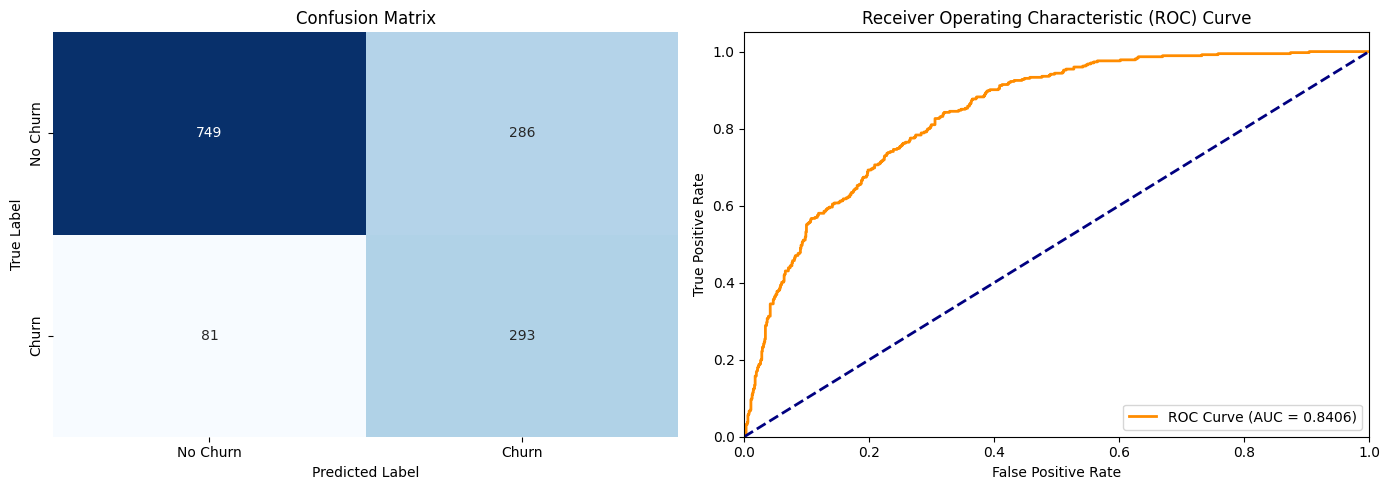


--- Step 5: Exporting Final Production-Ready Pipeline ---
Successfully serialized and saved entire end-to-end pipeline to: 'telco_churn_pipeline.joblib'
Pipeline deployment verification passed! Loaded pipeline test ROC-AUC: 0.8406


In [2]:
# ==========================================
# 1. SETUP & REAL DATASET EXTRACTION
# ==========================================
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib

# Set random seed for reproducibility
np.random.seed(42)

zip_path = '/content/telco churn dataset.zip'
extract_dir = '/content/telco_churn_extracted'

print("--- Step 1: Extracting and Loading Dataset ---")

# Verify if the zip file exists
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Could not find the zip file at {zip_path}. Please ensure it is uploaded to your Colab session.")

# Unzip the archive
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    print(f"Extracted zip file contents to: {extract_dir}")

# Dynamically find the CSV file within the extracted contents
extracted_files = [os.path.join(dp, f) for dp, dn, fn in os.walk(extract_dir) for f in fn if f.endswith('.csv')]
if not extracted_files:
    raise FileNotFoundError("No CSV file found inside the extracted zip directory.")

csv_path = extracted_files[0]
print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully with shape: {df.shape}\n")

# ==========================================
# 2. DATA CLEANING & PREPROCESSING PIPELINE
# ==========================================
print("--- Step 2: Preparing Preprocessing Pipelines ---")

# Drop unnecessary identifier columns if they exist
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Crucial fix for real Telco data: Convert 'TotalCharges' string spaces to NaNs safely
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan, regex=False))

# Separate features (X) and target variable (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Identify numeric and categorical columns dynamically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features detected: {numeric_features}")
print(f"Categorical features detected: {categorical_features}")

# Numeric feature pipeline: Median imputation + Feature scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical feature pipeline: Mode imputation + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine everything via ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Split into Train and Test sets (Stratified to handle class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data split completed (80% Train, 20% Test).\n")

# ==========================================
# 3. MODEL DEVELOPMENT & HYPERPARAMETER TUNING
# ==========================================
print("--- Step 3: Model Training & Hyperparameter Tuning ---")

# Full estimation pipeline setup
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Define Search Grid. Note: We use 'class_weight' to tackle class imbalance dynamically
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=42)],
        'classifier__C': [0.01, 0.1, 1.0, 10.0]
    },
    {
        'classifier': [RandomForestClassifier(class_weight='balanced', random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None]
    }
]

# Run GridSearch using ROC-AUC as the scoring standard
grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Starting Grid Search across Logistic Regression & Random Forest architectures...")
grid_search.fit(X_train, y_train)

print(f"\nBest Model Found: {grid_search.best_params_['classifier'].__class__.__name__}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}\n")

best_pipeline = grid_search.best_estimator_

# ==========================================
# 4. EVALUATION & VISUALIZATIONS
# ==========================================
print("--- Step 4: Evaluating Best Model on Test Dataset ---")

y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot performance indicators
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# ==========================================
# 5. PIPELINE EXPORTATION
# ==========================================
print("\n--- Step 5: Exporting Final Production-Ready Pipeline ---")
model_filename = 'telco_churn_pipeline.joblib'
joblib.dump(best_pipeline, model_filename)
print(f"Successfully serialized and saved entire end-to-end pipeline to: '{model_filename}'")

# Final verification verification
loaded_pipeline = joblib.load(model_filename)
test_sanity_score = roc_auc_score(y_test, loaded_pipeline.predict_proba(X_test)[:, 1])
print(f"Pipeline deployment verification passed! Loaded pipeline test ROC-AUC: {test_sanity_score:.4f}")